n = 58
среднняя X 42.58620689655173
среднняя Y 559.0172413793101
СКО X 16.884020687557893
СКО Y 413.41248047571065
Заметная обратная зависимость
r_xy = -0.5776885005968908
Нулевая гипотеза отвергается, T = -5.296154579662938


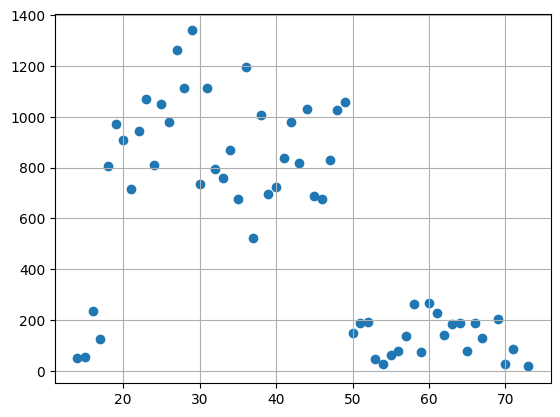

Dвнгр = 6.140089829516906
Dмежгр = 138.776878235298
D = 144.91696806481582
Dвнгр + Dмежгр = 144.9169680648149
Корреляционное соотношение = 0.9785858626416836
Nxi Nyi di di^2
1.0 5.0 -4.0 16.0
2.0 6.0 -4.0 16.0
3.0 24.0 -21.0 441.0
4.0 12.0 -8.0 64.0
5.0 37.0 -32.0 1024.0
6.0 45.0 -39.0 1521.0
7.0 43.0 -36.0 1296.0
8.0 32.0 -24.0 576.0
9.0 44.0 -35.0 1225.0
10.0 53.0 -43.0 1849.0
11.0 38.0 -27.0 729.0
12.0 51.0 -39.0 1521.0
13.0 47.0 -34.0 1156.0
14.0 57.0 -43.0 1849.0
15.0 54.0 -39.0 1521.0
16.0 58.0 -42.0 1764.0
17.0 34.0 -17.0 289.0
18.0 55.0 -37.0 1369.0
19.0 36.0 -17.0 289.0
20.0 35.0 -15.0 225.0
21.0 42.0 -21.0 441.0
22.0 28.0 -6.0 36.0
23.0 56.0 -33.0 1089.0
24.0 27.0 -3.0 9.0
25.0 48.0 -23.0 529.0
26.0 31.0 -5.0 25.0
27.0 33.0 -6.0 36.0
28.0 41.0 -13.0 169.0
29.0 46.0 -17.0 289.0
30.0 39.0 -9.0 81.0
31.0 50.0 -19.0 361.0
32.0 30.0 2.0 4.0
33.0 29.0 4.0 16.0
34.0 40.0 -6.0 36.0
35.0 49.0 -14.0 196.0
36.0 52.0 -16.0 256.0
37.0 16.0 21.0 441.0
38.0 18.5 19.5 380.25
39.0 21.0 18.0 3

In [1]:
from StatAnalysis import *
from math import *
import matplotlib.pyplot as plt
import copy
with open("Москва_2021.txt", "r") as f:
    d_row = create_discrete_series([int(l.strip()) for l in f])

def covariation(row): #Ковариация
    covar = 0.0
    x_a = 0.0
    y_a = 0.0
    for i in range(len(row)):
        x_a += row[i][0] / len(row)
        y_a += row[i][1] / len(row)
    for i in range(len(row)):
        covar += ((row[i][0] - x_a) * (row[i][1] - y_a)) / len(row)
    return covar

def standard_deviations_for_x_y(row): #Стандартные отклонения (и средние) для x и y, оформленные в виде словаря.
    result = []
    x_a = 0.0
    x_a2 = 0.0
    y_a = 0.0
    y_a2 = 0.0
    x_sd = 0.0
    y_sd = 0.0
    for i in range(len(row)):
        x_a += row[i][0] / len(row)
        x_a2 += (row[i][0] * row[i][0]) / len(row)
        y_a += row[i][1] / len(row)
        y_a2 += (row[i][1] * row[i][1]) / len(row)
    x_sd = sqrt(x_a2 - (x_a ** 2))
    y_sd = sqrt(y_a2 - (y_a ** 2))
    return {"среднняя X": x_a, "среднняя Y": y_a, "СКО X": x_sd, "СКО Y": y_sd}

def correlation_coefficient(row, print_result = False): #Коэффициент корреляции
    r_xy = covariation(row) / (standard_deviations_for_x_y(row)["СКО X"] * standard_deviations_for_x_y(row)["СКО Y"])
    if print_result:
        print_res = ""
        if 0 < abs(r_xy) <= 0.3:
            print_res = "Слабая "
            if r_xy < 0:
                print_res += "обратная "
            else:
                print_res += "прямая "
            print_res += "зависимость"
        elif 0.3 < abs(r_xy) <= 0.5:
            print_res = "Умеренная "
            if r_xy < 0:
                print_res += "обратная "
            else:
                print_res += "прямая "
            print_res += "зависимость"
        elif 0.5 < abs(r_xy) <= 0.7:
            print_res = "Заметная "
            if r_xy < 0:
                print_res += "обратная "
            else:
                print_res += "прямая "
            print_res += "зависимость"
        elif 0.7 < abs(r_xy) < 1:
            print_res = "Сильная "
            if r_xy < 0:
                print_res += "обратная "
            else:
                print_res += "прямая "
            print_res += "зависимость"
        elif abs(r_xy) == 1:
            print_res = "Функциональная"
            if r_xy < 0:
                print_res += "обратная "
            else:
                print_res += "прямая "
            print_res += "зависимость"
        print(print_res)
    return r_xy

def check_hypothesis(row):
    T_crit = 2.01 #ВЗЯТО ИЗ ТАБЛИЦЫ критических точек распределения Стьюдента!!!! Для k = n - 2 = 58 - 2 = 56 = 2.01
    T = (correlation_coefficient(row) * sqrt(len(row) - 2)) / sqrt(1 - (correlation_coefficient(row)**2))
    if abs(T) < T_crit:
        print("Нет оснований отвергнуть нулевую гипотезу, T =", T)
    else:
        print("Нулевая гипотеза отвергается, T =", T)

print("n =", len(d_row))
for key in standard_deviations_for_x_y(d_row).keys():
    print(key, standard_deviations_for_x_y(d_row)[key])
print("r_xy =", correlation_coefficient(d_row, True))
check_hypothesis(d_row)
x = [c[0] for c in d_row]
y = [c[1] for c in d_row]
plt.grid(True)
plt.scatter(x, y)
plt.show()


######### Лабораторная 4.2
with open("Москва_2021.txt", "r") as f: #Не использовался
    i_row = create_interval_series([int(l.strip()) for l in f])

def group_averages(row, n = 7): #Групповые средние (в качестве аргумента берётся дискретный ряд!)
    g_a = []
    h = ceil(len(row) / n)
    for i in range(n):
        g_a.append(0.0)
        g = 0.0
        for j in range(h):
            try:
                g += row[i * h + j][1]
                g_a[i] += row[i * h + j][0] * row[i * h + j][1]
            except IndexError:
                g_a[i] += 0.0
        g_a[i] = g_a[i] / g
    return g_a

def group_average(row, n = 7): #Общая средняя, то же самое, что и sample_mean()
    g_a = []
    g_list = []
    group_aver = 0.0
    h = ceil(len(row) / n)
    for i in range(n):
        g_a.append(0.0)
        g = 0.0
        for j in range(h):
            try:
                g += row[i * h + j][1]
                g_a[i] += row[i * h + j][0] * row[i * h + j][1]
            except IndexError:
                g_a[i] += 0.0
        g_a[i] = g_a[i] / g
        g_list.append(g)
    for i in range(len(g_a)):
        group_aver += g_a[i] * g_list[i]
    return group_aver / sum(g_list)

def group_dispersions(row, n = 7): #Групповые дисперсии (в качестве аргумента берётся дискретный ряд!)
    d_gr = []
    h = ceil(len(row) / n)
    for i in range(n):
        d_gr.append(0.0)
        g = 0.0
        for j in range(h):
            try:
                g += row[i * h + j][1]
                d_gr[i] += ((row[i * h + j][0] - group_averages(row, n)[i]) ** 2) * row[i * h + j][1]
            except IndexError:
                d_gr[i] += 0.0
        d_gr[i] = d_gr[i] / g
    return d_gr

def within_group_dispersion(row, n = 7): #Внутригрупповая дисперсия для интервального ряда
    d_gr = []
    h = ceil(len(row) / n)
    Nj = []
    D = 0.0
    for i in range(n):
        d_gr.append(0.0)
        g = 0.0
        for j in range(h):
            try:
                g += row[i * h + j][1]
                d_gr[i] += ((row[i * h + j][0] - group_averages(row, n)[i]) ** 2) * row[i * h + j][1]
            except IndexError:
                d_gr[i] += 0.0
        d_gr[i] = d_gr[i] / g
        Nj.append(g)
    for i in range(len(d_gr)):
        D += d_gr[i] * Nj[i]
    return D / sum(Nj)

def between_group_dispersion(row, n = 7): #Межгрупповая дисперсия для интервального ряда
    h = ceil(len(row) / n)
    Nj = []
    a = group_averages(row, n)
    D_bg = 0.0
    for i in range(n):
        g = 0.0
        for j in range(h):
            try:
                g += row[i * h + j][1]
            except IndexError:
                pass
        Nj.append(g)
    for i in range(len(a)):
        D_bg += ((a[i] - group_average(row, n)) ** 2) * Nj[i]
    return D_bg / sum(Nj)

def ranks(row): #Вычисление рангов
    indexed_row_x = [[row[i][0], i] for i in range(len(row))]
    indexed_row_y = [[row[i][1], i] for i in range(len(row))]
    indexed_row_x = sorted(indexed_row_x, key=lambda x: x[0])
    indexed_row_y = sorted(indexed_row_y, key=lambda x: x[0])
    out_row = [[0, 0]] * len(row)

    n = len(indexed_row_x)
    i = 0
    while i < n:
        j = i
        while j + 1 < n and indexed_row_x[j + 1][0] == indexed_row_x[i][0]:
            j += 1
        average_rank = sum(range(i + 1, j + 2)) / (j - i + 1)
        for k in range(i, j + 1):
            indexed_row_x[k][0] = average_rank
        i = j + 1
    
    n = len(indexed_row_y)
    i = 0
    while i < n:
        j = i
        while j + 1 < n and indexed_row_y[j + 1][0] == indexed_row_y[i][0]:
            j += 1
        average_rank = sum(range(i + 1, j + 2)) / (j - i + 1)
        for k in range(i, j + 1):
            indexed_row_y[k][0] = average_rank
        i = j + 1

    indexed_row_x = sorted(indexed_row_x, key=lambda x: x[1])
    indexed_row_y = sorted(indexed_row_y, key=lambda x: x[1])
    for i in range(len(out_row)):
        out_row[i] = [indexed_row_x[i][0], indexed_row_y[i][0]]
    
    return out_row

def rank_correlation_coefficient(row):
    rnks = ranks(row)
    r = 0.0
    for i in range(len(rnks)):
        r += 6 * (rnks[i][0] - rnks[i][1])**2
    r = r / (len(rnks) * (len(rnks)**2 - 1.0))
    r = 1 - r
    return r

print("Dвнгр =", within_group_dispersion(d_row))
print("Dмежгр =", between_group_dispersion(d_row))
print("D =", dispersion(d_row))
print("Dвнгр + Dмежгр =", within_group_dispersion(d_row) + between_group_dispersion(d_row))
print("Корреляционное соотношение =", sqrt(between_group_dispersion(d_row) / dispersion(d_row)))
print("Nxi Nyi di di^2")
for i in range(len(ranks(d_row))):
    print(ranks(d_row)[i][0], ranks(d_row)[i][1], ranks(d_row)[i][0] - ranks(d_row)[i][1], (ranks(d_row)[i][0] - ranks(d_row)[i][1])**2)
print("R =", rank_correlation_coefficient(d_row))
